# The "Spine" on the Wall: Role of Regularity

This notebook demonstrates the concept discussed in **The Core Difficulty: Data to Functions**. 

We are given a set of finite constraints—points nailed to a wall—and we must infer the shape of the object (the function) that connects them. 

This illustrates that data alone is often insufficient to determine a useful function; we need **regularity assumptions** (like the *stiffness* of a physical spine) to make the learning problem well-posed and the solution useful for unseen data.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Ensure reproducible results
np.random.seed(42)

## 1. The "Nailed" Data Constraints

Imagine we have a set of finite observations. These are our "nails". Any valid solution *must* pass through (or very close to) these points.

We generate these points from an underlying "ground truth" (a sine wave) that we want to discover, but in the real world, we only see the points, not the sine wave.

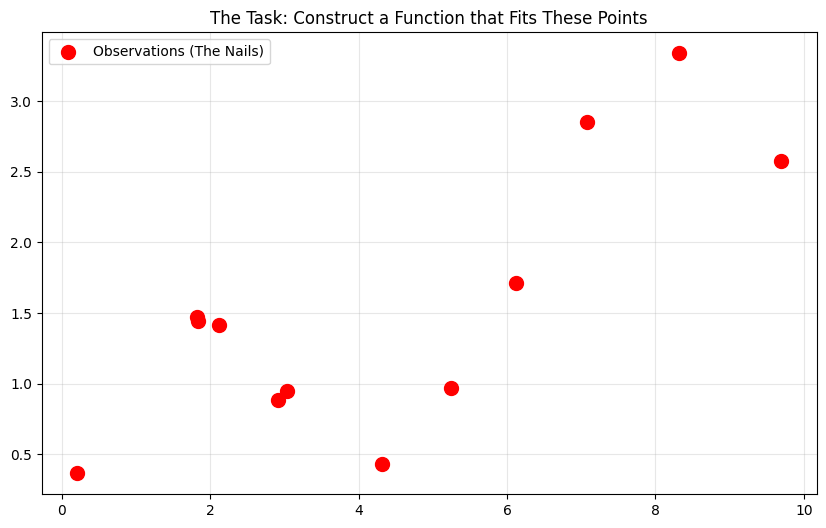

In [29]:
# 1. Generate "Nailed" Points (The Training Data)
n_trn = 12
x_nails = np.random.uniform(0, 10, n_trn)  # Randomly place 6 nails along the wall
x_nails = np.sort(x_nails)
y_nails = np.sin(x_nails) + x_nails*0.3 + np.random.normal(0, 0.1, x_nails.shape) # Sine wave with some noise

# Visualize the constraints
plt.figure(figsize=(10, 6))
plt.scatter(x_nails, y_nails, color='red', s=100, label='Observations (The Nails)', zorder=5)
plt.title("The Task: Construct a Function that Fits These Points")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Fitting Without "Regularity" (The Chaotic Polynomial)

If our only requirement is "the function must hit the nails", there are infinitely many solutions. 

A high-degree polynomial can pass through every single point perfectly. However, without a "stiffness" (regularity) constraint, it tends to oscillate wildly between points. This is analogous to a piece of string that is too loose—it fits the points but doesn't capture the underlying structure. 

In Machine Learning, this is often called **Overfitting**.

In [30]:
# 2. Fit a high-degree polynomial (Degree = N-1 passes through all N points)
# This represents a "hypothesis" with high complexity and no regularity constraint.
poly_deg = n_trn - 1
coeffs_poly = np.polyfit(x_nails, y_nails, poly_deg)
func_poly = np.poly1d(coeffs_poly)

# Generate dense points for plotting the curve
x_dense = np.linspace(0, 10, 200)
y_poly = func_poly(x_dense)

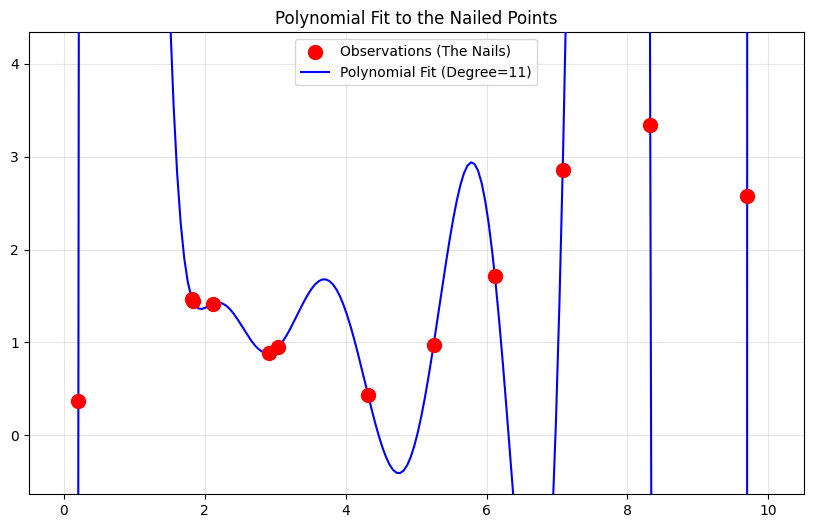

In [ ]:
import matplotlib.pyplot as plt
# Visualize the polynomial fit
plt.figure(figsize=(10, 6))
plt.scatter(x_nails, y_nails, color='red', s=100, label='Observations (The Nails)', zorder=5)
plt.plot(x_dense, y_poly, color='blue', label=f'Polynomial Fit (Degree={poly_deg})', zorder=4)
plt.title("Polynomial Fit to the Nailed Points")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(np.min(y_nails)-1, np.max(y_nails)+1)
plt.show()


## 3. Fitting With "Regularity" (The Spine)

Now we apply the "Spine" metaphor. A physical spine resists bending. It tries to pass through the points while minimizing its internal energy (curvature).

Mathematically, a **Cubic Spline** mimics this property. It finds a function that is continuous, has continuous derivatives (smooth), and minimizes the "wiggliness".

This "resistance to bending" is the **Regularity** assumption. It is what allows us to fill in the gaps between the nails sensibly.

In [33]:
# 3. Fit a Cubic Spline
# This enforces continuity in the function and its first two derivatives (Smoothness)
func_spline = CubicSpline(x_nails, y_nails)
y_spline = func_spline(x_dense)

## 4. Visual Comparison

Let's look at the difference.

*   **Red Dots:** The Information we have (Data).
*   **Green Line (Polynomial):** A "smart" function that memorizes the data but has no regularity. It fails to generalize.
*   **Blue Line (Spline):** A function constrained by regularity. It captures the true shape.

**Takeaway:** In Machine Learning, the "Regularity" (or Inductive Bias) is just as important as the Data itself. Without it, we just connect the dots wildly.

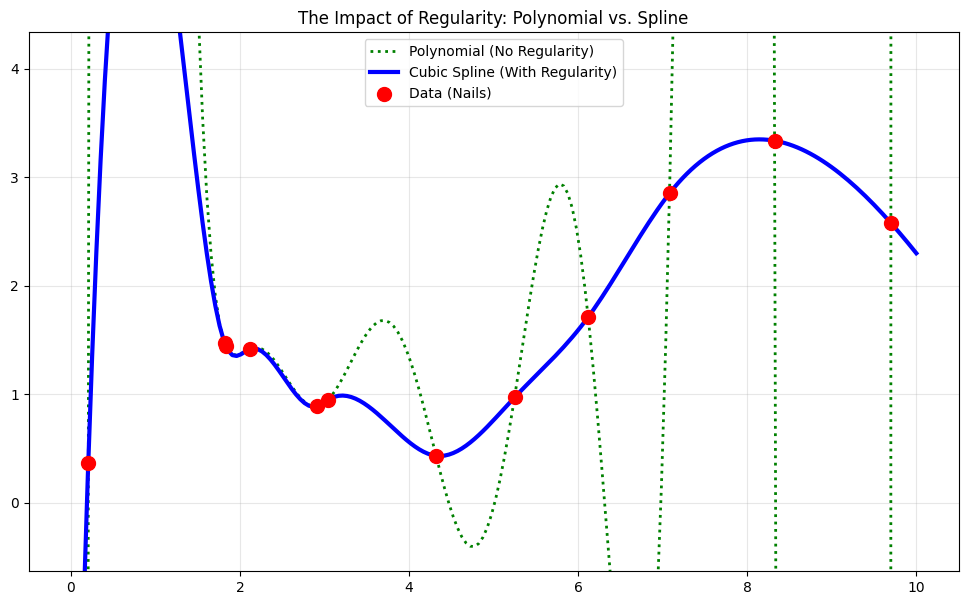

In [35]:
plt.figure(figsize=(12, 7))

# Plot truth (optional, for reference)
# plt.plot(x_dense, np.sin(x_dense), 'k--', alpha=0.3, label='Ground Truth (Unknown to Machine)')

# Plot Models
plt.plot(x_dense, y_poly, color='green', linestyle=':', linewidth=2, label='Polynomial (No Regularity)')
plt.plot(x_dense, y_spline, color='blue', linewidth=3, label='Cubic Spline (With Regularity)')

# Plot Data
plt.scatter(x_nails, y_nails, color='red', s=100, label='Data (Nails)', zorder=5)

plt.title("The Impact of Regularity: Polynomial vs. Spline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(np.min(y_nails)-1, np.max(y_nails)+1)
plt.show()